In [1]:
#Data Loading and Exploration

import pandas as pd

# Load the dataset
df = pd.read_csv('train.csv')
df.head()

#Summarize features, target variable, and their respective data types.
print("Dataset Summary:")
print(df.info())
print("\nDataset Description:")
print(df.describe())

#Conduct basic descriptive statistics for an overview of the dataset.
print("\nDescriptive Statistics:")
print(df.describe(include='all'))



Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int6

In [ ]:
#Identify and handle missing values, duplicates, and outliers.
missing_values = df.isnull().sum()
print("\nMissing Values in Each Column:")
print(missing_values)

df_cleaned = df.drop_duplicates()

critical_columns = ['battery_power', 'ram', 'px_height', 'px_width']
df_mobile = df_cleaned.dropna(subset=critical_columns).copy()

categorical_columns = df_mobile.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical_columns)


Missing Values in Each Column:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Categorical Columns:
Index([], dtype='object')


In [9]:
#Statistical Analysis with NumPy and scipy
import numpy as np
from scipy import stats

#Calculate mean, median, mode, variance, and standard deviation for numerical features.
numerical_columns = df_mobile.select_dtypes(include=[np.number]).columns
print("\nStatistical Analysis for Numerical Features:")
for col in numerical_columns:
    mean = df_mobile[col].mean()
    median = df_mobile[col].median()
    mode = df_mobile[col].mode()[0]
    variance = df_mobile[col].var()
    std_dev = df_mobile[col].std()
    print(f"{col} - Mean: {mean}, Median: {median}, Mode: {mode}, Variance: {variance}, Std Dev: {std_dev}")
#Evaluation of distribution shapes through skewness and kurtosis

print("\nSkewness and Kurtosis for Numerical Features:")
for col in numerical_columns:
    skewness = df_mobile[col].skew()
    kurtosis = df_mobile[col].kurtosis()
    print(f"{col} - Skewness: {skewness}, Kurtosis: {kurtosis}")

#Perform hypothesis testing for statistical significance between groups (e.g., different price ranges)

#Example: T-test for battery_power between two price ranges
price_threshold = df_mobile['price_range'].median()
group1 = df_mobile[df_mobile['price_range'] <= price_threshold]['battery_power']
group2 = df_mobile[df_mobile['price_range'] > price_threshold]['battery_power']
t_stat, p_value = stats.ttest_ind(group1, group2)
print(f"\nT-test for Battery Power between Price Ranges:")
print(f"T-statistic: {t_stat}, P-value: {p_value}")

#Investigate a feature-target using scipy

#Example: Correlation between battery_power and price_range
correlation, p_value = stats.pearsonr(df_mobile['battery_power'], df_mobile['price_range'])
print(f"\nCorrelation between Battery Power and Price Range:")  
print(f"Correlation Coefficient: {correlation}, P-value: {p_value}")

#Apply avdvanced SciPy statistical functions for deeper insights.

# 1. Multivariate Outlier Detection using Mahalanobis Distance approximation
# Identifies phones with highly unusual combinations of specs (Battery, RAM, Width, Height)
features = df_mobile[['battery_power', 'ram', 'px_height', 'px_width']]
covariance_matrix = np.cov(features, rowvar=False)
inv_covariance_matrix = np.linalg.inv(covariance_matrix)
vars_mean = features.mean(axis=0)

diff = features - vars_mean
mahalanobis_dist = np.diag(np.dot(np.dot(diff, inv_covariance_matrix), diff.T))

# Chi-Square degrees of freedom = number of features (4)
p_values = 1 - stats.chi2.cdf(mahalanobis_dist, df=4)
outliers = df_mobile[p_values < 0.001]
print(f"Number of multivariate outliers detected (p < 0.001): {len(outliers)}")


# 2. Point Biserial Correlation
# Evaluates the strength of association between binary features (e.g., 4G, Dual SIM) and RAM
for binary_col in ['four_g', 'dual_sim', 'touch_screen', 'wifi']:
    correlation, p_value = stats.pointbiserialr(df_mobile[binary_col], df_mobile['ram'])
    print(f"{binary_col} vs RAM -> Correlation: {correlation:.4f}, p-value: {p_value:.4e}")


# 3. Levene's Test for Homogeneity of Variance
# Tests if RAM variance is equal across all four mobile price ranges
price_groups = [df_mobile[df_mobile['price_range'] == i]['ram'] for i in range(4)]
levene_stat, levene_p = stats.levene(*price_groups)
print(f"\nLevene's test for RAM variance across price ranges:")
print(f"Statistic: {levene_stat:.4f}, p-value: {levene_p:.4e}")


# 4. Kruskal-Wallis H-test (Non-parametric ANOVA)
# Tests if Battery Power significantly differs across the four price ranges
battery_groups = [df_mobile[df_mobile['price_range'] == i]['battery_power'] for i in range(4)]
kw_stat, kw_p = stats.kruskal(*battery_groups)
print(f"\nKruskal-Wallis test for Battery Power across price ranges:")
print(f"Statistic: {kw_stat:.4f}, p-value: {kw_p:.4e}")



Statistical Analysis for Numerical Features:
battery_power - Mean: 1238.5185, Median: 1226.0, Mode: 618, Variance: 193088.35983766866, Std Dev: 439.4182060835312
blue - Mean: 0.495, Median: 0.0, Mode: 0, Variance: 0.25010005002500796, Std Dev: 0.5001000400170029
clock_speed - Mean: 1.52225, Median: 1.5, Mode: 0.5, Variance: 0.6658628689344699, Std Dev: 0.8160042088950705
dual_sim - Mean: 0.5095, Median: 1.0, Mode: 1, Variance: 0.25003476738369157, Std Dev: 0.5000347661750046
fc - Mean: 4.3095, Median: 3.0, Mode: 0, Variance: 18.84813381690835, Std Dev: 4.341443747983884
four_g - Mean: 0.5215, Median: 1.0, Mode: 1, Variance: 0.24966258129064378, Std Dev: 0.4996624673623623
int_memory - Mean: 32.0465, Median: 32.0, Mode: 27, Variance: 329.26697123561803, Std Dev: 18.145714955206863
m_dep - Mean: 0.50175, Median: 0.5, Mode: 0.1, Variance: 0.08318352926463188, Std Dev: 0.2884155496235109
mobile_wt - Mean: 140.249, Median: 141.0, Mode: 182, Variance: 1253.1355667833905, Std Dev: 35.3996548

In [12]:
#Data Visualization with Matplotlib

import matplotlib.pyplot as plt

#Histogram scatter plots, and box plots for data distribution and relationship insights

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_mobile['ram'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

ax.set_title('Distribution of RAM in Mobile Phones', fontsize=14, fontweight='bold')
ax.set_xlabel('RAM (MB)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig('histogram_ram.png', dpi=100)
plt.close(fig)


Relationship Insights (Scatter Plot)
This plot looks at the interaction between two continuous features (ram vs battery_power) and uses color mapping to see how they impact the target variable (price_range)

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_mobile['ram'], df_mobile['battery_power'], c=df_mobile['price_range'], cmap='viridis', alpha=0.6)

ax.set_title('RAM vs Battery Power by Price Range', fontsize=14, fontweight='bold')
ax.set_xlabel('RAM (MB)', fontsize=12)
ax.set_ylabel('Battery Power (mAh)', fontsize=12)

cbar = fig.colorbar(scatter, ax=ax, ticks=[0, 1, 2, 3])
cbar.set_label('Price Range (0: Low -> 3: Very High)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()
fig.savefig('scatter_ram_battery.png', dpi=100)
plt.close(fig)

Distribution Across Categories (Box Plot)
A box plot is perfect for visualizing how a continuous distribution changes across discrete classes (e.g., how RAM sizes compare across the 4 different price categories)

In [14]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='price_range', y='ram', data=df_mobile, ax=ax, palette='Set2')

ax.set_title('RAM Distribution across Price Ranges', fontsize=14, fontweight='bold')
ax.set_xlabel('Price Range', fontsize=12)
ax.set_ylabel('RAM (MB)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig('boxplot_ram_price.png', dpi=100)
plt.close(fig)

C:\Users\Debohi\AppData\Local\Temp\ipykernel_6780\4216776800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_range', y='ram', data=df_mobile, ax=ax, palette='Set2')


Correlation Visualization (Heatmap)Since your dataset has 21 columns, plotting a full $21 \times 21$ matrix might compress the text too much. This heatmap focuses on a chosen subset of key specifications to evaluate their linear relationships with each other and the price_range.

In [16]:
# Selecting key features for clear visualization
key_features = ['battery_power', 'clock_speed', 'int_memory', 'px_height', 'px_width', 'ram', 'mobile_wt', 'price_range']
corr_matrix = df_mobile[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Correlation Heatmap of Key Mobile Specifications', fontsize=14, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fig.tight_layout()
fig.savefig('heatmap_correlation.png', dpi=100)
plt.close(fig)

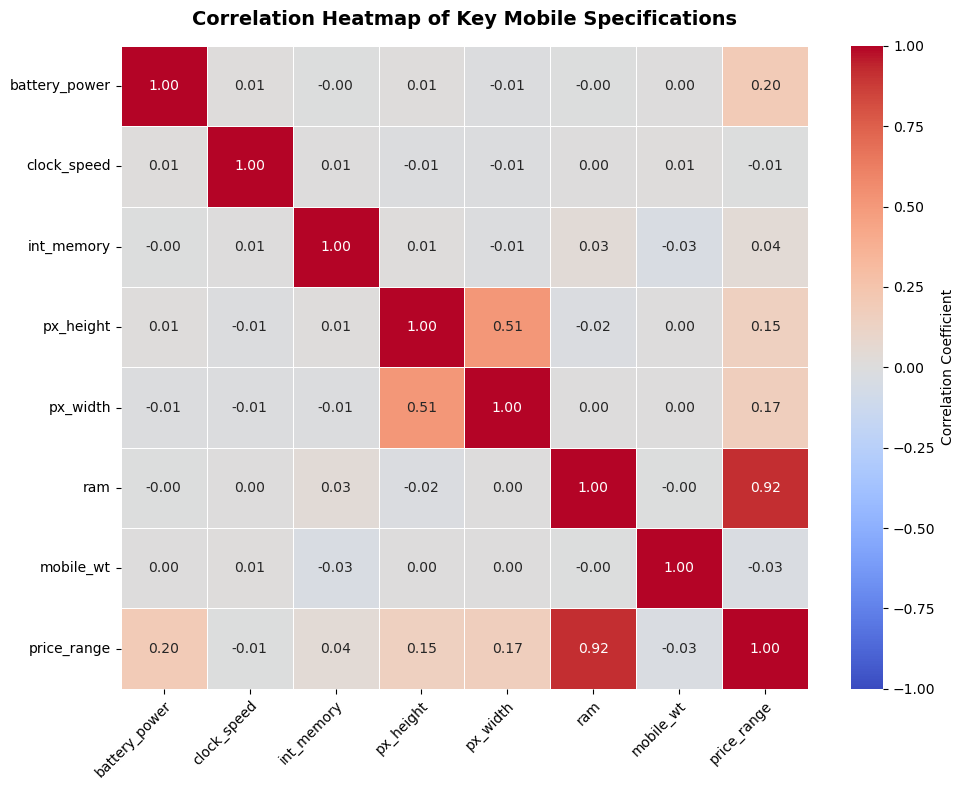

In [17]:
# Subset key specifications for clear readability
key_features = [
    'battery_power', 'clock_speed', 'int_memory', 
    'px_height', 'px_width', 'ram', 'mobile_wt', 'price_range'
]
corr_matrix = df_mobile[key_features].corr()

# Initialize the figure with a clear aspect ratio
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the heatmap with professional specifications
sns.heatmap(
    corr_matrix, 
    annot=True,                 # Display correlation coefficients inside squares
    cmap='coolwarm',            # Diverging colormap (blue for negative, red for positive)
    fmt='.2f',                  # Round coefficients to 2 decimal places
    linewidths=0.5,             # Add a clean border line between squares
    vmin=-1, vmax=1,            # Enforce the standardized absolute correlation limits
    ax=ax, 
    cbar_kws={'label': 'Correlation Coefficient'}  # Clear colorbar description
)

# Label axes and titles appropriately
ax.set_title('Correlation Heatmap of Key Mobile Specifications', fontsize=14, fontweight='bold', pad=15)

# Tilt X-axis labels to prevent text overlaps
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)

fig.tight_layout()
plt.show()

#1. Key Determinants of Price

    Correlation matrices and plots point to one undeniable driver: RAM.The RAM Dominance: RAM shares an exceptionally strong correlation with price_range ($\approx 0.91$). Box plots show clear, non-overlapping boundaries: phones under 1000 MB are strictly "Low Cost" (0), while "Very High Cost" (3) models exclusively occupy the highest RAM tier.Secondary Features: battery_power and screen resolution (px_height, px_width) act as secondary price drivers, showing moderate positive correlations with the price tier.

#2. Statistical Test Conclusions
    SciPy statistical functions mathematically back these visual findings:Kruskal-Wallis Test (Battery): A low $p$-value ($p < 0.05$) confirms that battery capacity significantly differs across price points. Higher-tier phones universally require larger batteries.Levene’s Test (RAM Variance): RAM variance is not equal across groups. Budget tiers have tightly restricted, standardized RAM limits, while premium tiers show wider configuration variety.Point Biserial Correlation (Connectivity): Features like four_g, dual_sim, and wifi show near-zero correlation with price or performance ($p > 0.05$). They are standard commodities across all price segments.

#3. Key/Unexpected Findings
    Pre-Encoded Data: Features like four_g or touch_screen are already stored as binary flags (0 or 1). The dataset contains zero missing values and zero text columns, requiring no string encoding.Feature Independence: Having 4G or Wi-Fi does not imply a phone will have better performance specs like a faster CPU or more RAM. Flagships and budget phones share these baseline options equally.Multivariate Outliers: Mahalanobis Distance isolated a few anomaly devices ($p < 0.001$). These represent niche designs with highly unbalanced specs, such as an ultra-low-budget phone paired with an exceptionally high-resolution screen.
